# Install packages

In [ ]:
!pip install control mujoco mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.6/549.6 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.0 MB/s eta 0:00:00


# Imports

In [ ]:
# Imports
import numpy as np
import control
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from ipywidgets import interact, widgets
# Change to glfw when on Mac. This might fuck up the lighting.
%env MUJOCO_GL=egl
import mujoco
import mujoco.viewer
import mediapy as media

env: MUJOCO_GL=egl


# MuJoCo
MuJoCo, short for Multi-Joint dynamics with Contact, is a physics engine widely used in robotics, biomechanics, graphics, and machine learning research. Developed by Emo Todorov at the University of Washington, MuJoCo excels in simulating complex dynamic systems with articulated bodies and contact dynamics. Its efficient computation of forward and inverse dynamics, coupled with accurate collision detection, enables researchers to model intricate interactions between objects and environments. MuJoCo's popularity stems from its user-friendly interface, high-performance simulation capabilities, and extensive documentation, making it a go-to tool for simulating and testing a wide range of robotic and physical systems.

We here only give a very brief introduction. There exists a more complete [tutorial](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/tutorial.ipynb) by Google Deepmind. The framework is also extensively documented [[link](https://mujoco.readthedocs.io/en/stable/)].

In [ ]:
# Mujoco simulations can be defined in xml format. We here create a simple simulation with 3 objects.
xml = """
<mujoco>
  <worldbody>
    <geom size="1 1 .01" type="plane" pos="0 0 -1"/>
    <light name="top" pos="0 0 10"/>
    <body name="pendulum" euler="30 -30 0">
      <joint name="swing" type="hinge" axis="1 -1 0" pos="-.4 0 0"/>
      <geom name="pendulum" type="cylinder" pos="-.4 0 -.2"
        size=".04 .2" rgba=".5 .5 .5 1"/>
    </body>
    <body name="box" euler="30 30 30" >
      <freejoint name="box_joint"/>
      <geom name="box" type="box" size=".1 .1 .1" rgba="1 0 0 1"/>
    </body>
    <body name="ball" pos="0 0 .3">
      <freejoint name="ball_joint"/>
      <geom name="ball" type="sphere" size=".1 .1 .1" rgba="0 1 0 1"/>
    </body>
  </worldbody>
</mujoco>
"""

In [ ]:
# Make model. The mujoco model contains all quantities that do not change over time.
mj_model = mujoco.MjModel.from_xml_string(xml)
# The mujoco data contains the changing values, so the state of the model.
mj_data = mujoco.MjData(mj_model)
# The renderer takes care of rendering the model.
renderer = mujoco.Renderer(mj_model)

In [ ]:
# We here show the simulation of our created model.
duration = 3.8  # (seconds)
framerate = 60  # (Hz)
frames = []
# Reset dynamic stgate
mujoco.mj_resetData(mj_model, mj_data)
while mj_data.time < duration:
    # Simulation step
    mujoco.mj_step(mj_model, mj_data)
    if len(frames) < mj_data.time * framerate:
        # Render frame
        renderer.update_scene(mj_data)
        pixels = renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


### Tasks
1. Add some kind of object to the simulation. For geometric objects, MuJoCo implements [geom](https://mujoco.readthedocs.io/en/latest/XMLreference.html#body-geom). If you want he body to move, you need to implement a [joint](https://mujoco.readthedocs.io/en/latest/XMLreference.html#body-joint) for constrained movement, or a [freejoint](https://mujoco.readthedocs.io/en/latest/XMLreference.html#body-freejoint) for unconstrained movement.

In [ ]:
## Solution
import urllib.request
with urllib.request.urlopen("https://raw.githubusercontent.com/google-deepmind/mujoco/main/model/humanoid/humanoid.xml") as f:
    xml = f.read()

humanoid_model = mujoco.MjModel.from_xml_string(xml)
humanoid_data = mujoco.MjData(humanoid_model)
humanoid_renderer = mujoco.Renderer(humanoid_model)

duration = 3.8  # (seconds)
framerate = 60  # (Hz)
frames = []
mujoco.mj_resetData(humanoid_model, humanoid_data)
while humanoid_data.time < duration:
    mujoco.mj_step(humanoid_model, humanoid_data)
    if len(frames) < humanoid_data.time * framerate:
        humanoid_renderer.update_scene(humanoid_data)
        pixels = humanoid_renderer.render()
        frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


# PID Control
PID control, standing for Proportional-Integral-Derivative control, is a widely-used feedback control mechanism in engineering. It aims to regulate a system's behavior by continuously adjusting an input variable to maintain a desired output. The "Proportional" term reacts to the current error, the difference between the desired setpoint and the measured process variable. The "Integral" term accounts for past errors over time, ensuring steady-state accuracy and eliminating steady-state error. The "Derivative" term anticipates future behavior of the system by evaluating the rate of change of the error. By combining these three terms, PID controllers can effectively stabilize systems, improve transient response, and achieve desired performance criteria across various applications, from industrial processes to robotics and beyond. Fine-tuning PID parameters is crucial for optimal control performance, often requiring iterative adjustment and system understanding.

In [ ]:
# This is a very simple one dimensional system controlled by a PID controller.
# Adapted from here: https://github.com/Team334/notebooks/blob/master/PID.ipynb

def pid(errors, Kp, Ki, Kd, time_delta):
    current_error = errors[-1]
    if len(errors) > 1:
        prev_error = errors[-2]
    else:
        prev_error = current_error
    return Kp*current_error + Ki* sum(errors) * time_delta + Kd*(current_error - prev_error) / time_delta

# very simple second order system
v = 0
def process(a, s):
    global v
    v = v*0.9 + 0.05*a - 0.01
    return np.clip(s + v, 0, 3)

def simulate_pid(Kp, Ki, Kd):
    time_delta = 0.1
    duration = 30
    times = np.arange(0, duration, time_delta)
    target_trajectory = np.zeros(times.size)
    target_trajectory[50:] = 1

    states = np.zeros(times.size)
    states[0] = 0 # initial state

    errors = np.zeros(times.size)
    errors[0] = states[0] - target_trajectory[0]

    for i in range(1, len(times)):
        u = pid(errors[:i], Kp, Ki, Kd, time_delta=time_delta)
        state = process(u, states[i - 1])
        states[i] = state
        errors[i] = target_trajectory[i] - state

    return times, states, target_trajectory, errors

def animate(Kp, Ki, Kd):
    ax = plt.gca()
    ax.set_title("PID controller response")
    ax.set_xlabel("Time")
    ax.set_ylabel("State")
    t, s, d, e = simulate_pid(Kp, Ki, Kd)
    ax.plot(np.arange(0, 30, 0.1), d)
    ax.set_xlim(( 0, 30))
    ax.set_ylim((-1, 2))
    ax.plot(t,s)
    plt.legend(['target', 'state'])
    plt.show()

interact(
    animate,
    Kp=widgets.FloatSlider(value=0.0, min=-1, max=1, step=0.01, name='Kp'),
    Ki=widgets.FloatSlider(value=0.0, min=-1, max=1, step=0.01, name='Ki'),
    Kd=widgets.FloatSlider(value=0.0, min=-1, max=1, step=0.01, name='Kd')
)

interactive(children=(FloatSlider(value=0.0, description='Kp', max=1.0, min=-1.0, step=0.01), FloatSlider(valu…

<function __main__.animate(Kp, Ki, Kd)>

### Tasks:
1. Find a reasonable gain by trying around. There are several [heuristics](https://tlk-energy.de/blog-en/practical-pid-tuning-guide) to set these parameters.

# PID for inverted pendulum
In the following you will try to set the parameters for a simple 2D cartpole inverted pendulum model yourself. This example is often used to teach the basics of control. The model implements a cart of mass M that slides on a surface without any friction. At the center of mass of the cart, a pole is mounted with a rotational link without any friction. The pole is of length l itself has no mass. On its tip, a pointmass of mass m is attached. The cart is actuated by a motor that applies a force in x direction, while there is no actuation at the link between the cart and the pole.

In [ ]:
# return a mujoco model with the given physical parameters
def get_mj_model(m,M,l,g,k):
  xml = f"""
  <mujoco model='test_cartpole'>
    <compiler inertiafromgeom='true' coordinate='local'/>

    <size nkey="1"/>

    <option timestep='0.01' gravity='0 0 {-g}'/>

    <default>
      <joint damping='0.0' solreflimit='.08 1'/>
      <geom contype='0' friction='0. 0. 0.'/>
    </default>

    <worldbody>
      <camera name='fixed' pos='0 -2.5 0' quat='0.707 0.707 0 0'/>
      <light name="top" castshadow="false"/>
      <geom name='floor' pos='0 0 -1' size='4 4 4' type='plane' />
      <geom name='rail1' type='capsule' pos='0 .07 0' quat='0.707 0 0.707 0'
            size='0.02 1.2' />
      <geom name='rail2' type='capsule' pos='0 -.07 0' quat='0.707 0 0.707 0'
            size='0.02 1.2' />
      <body name='cart' pos='0 0 0'>
        <camera name='cart' pos='0 -2.5 0' quat='0.707 0.707 0 0' />
        <joint name='slider' type='slide' limited='true' pos='0 0 0'
                axis='1 0 0' range='-1 1' />
        <geom name='cart' type='box' pos='0 0 0'
                mass='{M}' size='0.2 0.1 0.05' rgba='0.7 0.7 0 1' />
        <site name='cart sensor' type='box' pos='0 0 0'
                size='0.2 0.1 0.05' rgba='0.7 0.7 0 0' />
        <body name='pole' pos='0 0 0'>
          <camera name='pole'  pos='0 -2.5 0' quat='0.707 0.707 0 0' />
          <joint name='hinge' type='hinge' pos='0 0 0' axis='0 1 0'/>
          <geom name='cpole' type='capsule' fromto='0 0 0 0 0 {l}'
                  mass='0' size='0.01 {l}' rgba='0 0.7 0.7 1' />
          <geom type='sphere' size='.05' name='tip' mass='{m}' pos='.001 0 {l}'/>
        </body>
      </body>
    </worldbody>

    <actuator>
      <motor name='slide' joint='slider' gear='{k}' ctrllimited='true' ctrlrange='-1 1' />
    </actuator>

  </mujoco>
  """
  return mujoco.MjModel.from_xml_string(xml)

In [ ]:
# Create a mujoco model for the given set of physical parameters.
m = 2
M = 5
l = 0.5
g = 9.81
k = 50
mj_model = get_mj_model(m,M,l,g,k)
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model)

In [ ]:
# Simulates the system with a closed loop controler with the given gain
def simulate(gain, path_frequency = 0):
    max_angle = np.pi/3
    duration = 10.  # (seconds)
    framerate = 60  # (Hz)

    frames = []
    mujoco.mj_resetData(mj_model, mj_data)
    mj_data.qvel = 0.1*np.random.randn(2) # velocities
    mj_data.qpos = 0.1*np.random.randn(2) # positions
    state = np.concatenate([mj_data.qpos, mj_data.qvel])
    if len(gain) == 6: # we later use state-feedback control that does not use the I gain
        state = np.concatenate([state, np.zeros(2)])
    trajectory = [list(state)]
    actions = []
    targets = []
    while mj_data.time < duration:
        x_target = 0.75*np.sin(mj_data.time*path_frequency*2*np.pi)
        targets.append(x_target)
        state_around_target = np.concatenate([state[:1] - x_target, state[1:]])
        u = mj_data.ctrl = - np.clip(np.dot(gain, state_around_target), -1, 1) # u = -K*(s-st)
        mujoco.mj_step(mj_model, mj_data)
        state[:4] = np.concatenate([mj_data.qpos, mj_data.qvel])
        if len(gain) == 6:
            state[4:] += state[2:4]
            state[4:] *= 0.9 # We implement a decay of the integrator
        trajectory.append(list(state))
        actions.append(u)
        if len(frames) < mj_data.time * framerate:
            renderer.update_scene(mj_data)
            pixels = renderer.render()
            frames.append(pixels)
        if np.abs(mj_data.qpos[1]) > max_angle:
            break
    trajectory = np.array(trajectory)
    actions = np.array(actions)
    media.show_video(frames, fps=framerate)
    l = ["x","$\\theta$", "x'", "$\\theta$'"] + (len(gain)==6)*["I(x)", "I($\\theta$)"]
    plt.plot(np.arange(len(trajectory))/100, trajectory,label=l)
    plt.plot(np.arange(len(actions))/100, actions, label = "u")
    plt.axhline(y=0., color='grey', linestyle='--')
    if path_frequency:
        plt.plot(np.arange(len(targets))/100, targets,label="$x_{target}$", c="black", linestyle="--")
    plt.legend()
    plt.xlabel('time[s]')
    return trajectory, actions

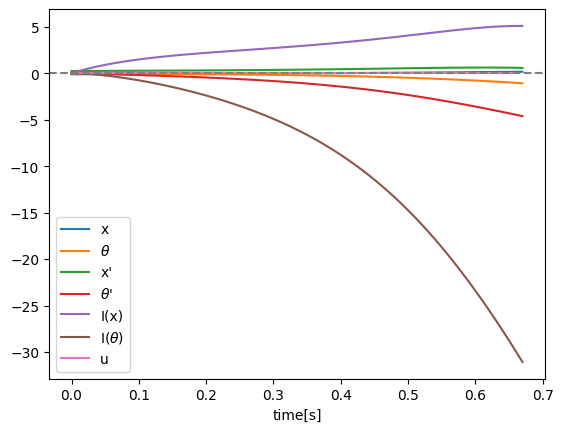

In [ ]:
## Main
# Set an appropriate gain
# gain = (p_x, p_theta, d_x, d_theta, i_x, i_theta)
gain = np.array([0., 0., 0., 0., 0., 0.])
trajectory, actions = simulate(gain)

How did we do? We can define a cost function that measures how well our controller did. Here we use a time-integral over a quadratic loss of both the difference of the state from its target and the control inputs. Note that comparing costs only makes sense if the simulation ran through, i.e., the pole did not fall down.

This browser does not support the video tag.


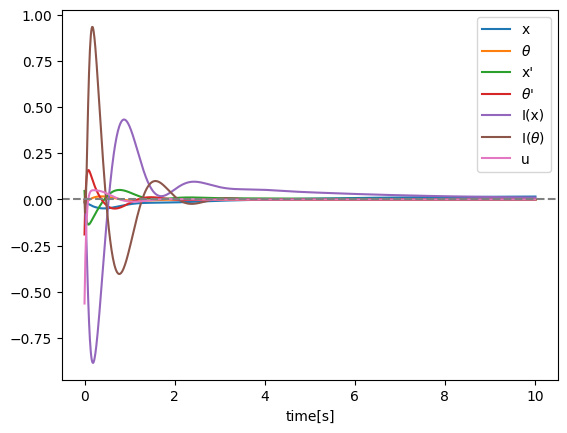

In [ ]:
## Solution
gain = np.array([-1., -10., -3., -3., -.1, -.1])
trajectory, actions = simulate(gain)

In [ ]:
# Definition of the matrices for the quadratic cost function J.
# Note that comparing costs only makes sense if the simulation ran through, i.e., the pole did not fall down.
Q = np.diag([1, 10, 0, 0, 0, 0])
R = 0.1
# Compute the cost function for the last trail run
def cost(trajectory, actions, Q, R):
    cost_state_diff = sum([np.matmul(np.matmul(v.T,Q),v) for v in trajectory])
    cost_control = sum([R*v*v for v in actions])
    J = cost_state_diff + cost_control
    return J
print(f"J = {cost(trajectory,actions,Q,R)}")

J = 0.5157581647075218


### Tasks
1. Find a reasonable gain by trying around. The pole should be balanced upwards for the full simulation time (10 sec). It is often easier to start with the proportional part of the gain (setting the differential part to zero) until you find a good configuration and then set a the integral part and then the differential part. Also it might be easier to start with the part for theta. You can use the cost function to asses how well your system did. There are several [heuristics](https://tlk-energy.de/blog-en/practical-pid-tuning-guide) to set these parameters. -> Note that we start out with random initial conditions. You should run the simulation several times to see how robust your controller is to initial conditions.
2. Explain the cost function. What do Q and R do?

**Task 2.** Explain the cost function. What do Q and R do?

**Ans:**
The cost-function quantifies what we want to optimize. Q here defines a quadratic cost on the state error and R defines a quadratic cost on the control input.

# LQR Control
Linear Quadratic Regulator (LQR) is a powerful control technique used in engineering to design optimal control systems for linear dynamic systems. LQR aims to minimize a cost function that penalizes both the state of the system and the control effort. By formulating the problem in terms of state feedback, LQR computes optimal control inputs that minimize this cost function while steering the system to a desired state. It achieves this by combining the system's dynamics, control objectives, and a weighting matrix to balance between tracking performance and control effort. LQR provides robust and efficient control solutions for a wide range of applications, including aerospace, automotive, and robotics, where linear models adequately capture the system's behavior. However, careful consideration of system modeling and tuning of weighting matrices is essential to ensure effective performance in practical implementations.

To use LQR, we need to figure out the equations of motion of the cartpole system and linearize them. In our case, we consider the state to be (x, $\theta$, $\frac{dx}{dt}$, $\frac{d\theta}{dt}$) and apply a control input $u$ to the cart that is multiplied by the gear ratio($k$) to get the force on the cart $F = k \cdot u$.

The cartpole is a relatively simple system that is often use to understand the basics of LQR. For a more impressive application you can go through this [tutorial](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/LQR.ipynb).


In [ ]:
## Main
A = np.array([[0, 0, 1, 0],
              [0, 0, 0, 1],
              [0, 0, 0, 0],
              [0, 0, 0, 0]
              ])
B = np.array([[0], [0], [0], [0]])
Q = np.diag([1, 10, 0, 0])
R = 0.1

In [ ]:
## Solution
A = np.array([[0, 0, 1, 0],
              [0, 0, 0, 1],
              [0, -g*m/M, 0, 0],
              [0, g/l*(1+m/M), 0, 0]
              ])
B = np.array([[0], [0], [k/M], [-k/(M*l)]])
Q = np.diag([1, 10, 0, 0])
R = 0.1

In [ ]:
# Compute Eigenvalues of Matrix A
eig = np.linalg.eig(A)[0]
print(f"Eigenvalues of A: {eig}")

Eigenvalues of A: [ 0.          0.          5.24099227 -5.24099227]


In [ ]:
# Compute rank of control matrix
rank = np.linalg.matrix_rank(control.ctrb(A,B))
print(f"Rank of control matrix: {rank}")

Rank of control matrix: 4


In [ ]:
# This computes the gain for the given system and cost matrices -> Note that this will fail if you did not change A and B
gain = control.lqr(A,B,Q,R)[0][0]
print(f"LQR gain: {gain}")

LQR gain: [ -3.16227766 -16.16201957  -3.08776552  -2.75139594]


This browser does not support the video tag.


J = 0.8911221448743681


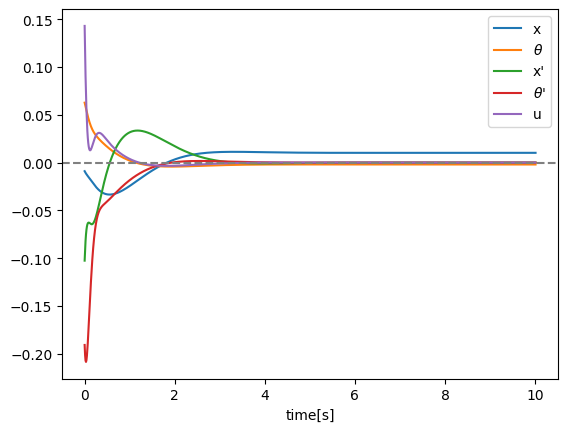

In [ ]:
# Simulate model
trajectory, actions = simulate(gain)
print(f"J = {cost(trajectory,actions,Q,R)}")

### Tasks
1. Derive the differential equations of motion (e.g., using Lagrange's Equation [[video](https://www.youtube.com/watch?v=Fo7kuUAHj3s)]).
2. Linearize the equations of motion at the cart standing at the origin ($x = 0$), the pole pointing upwards ($\theta = 0$) and the time differrentials set to zero ($\frac{dx}{dt} = \frac{d\theta}{dt} = 0$) [[video](https://www.youtube.com/watch?v=1Gf5urTHQsE)]. Insert the computed matrices A and B in the corresponding cell.
3. What do the eigenvalues of the matrix A tell you about the open-loop system?
4. What does the rank of the control matrix tell you about the closed-loop system?
5. Observe the closed loop system with the computed LQR control gain. Is the cost function lower than with your hand-designed controller?

**Task 3.** What do the eigenvalues of the matrix A tell you about the open-loop system?

**Ans:** Not stable since there are eigenvalues outside the negative half-plane.
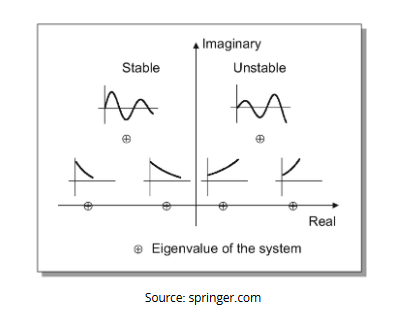

**Task 4.** What does the rank of the control matrix tell you about the closed-loop system>

**Ans:** Our system is controllable (there exists a feedback gain that stabilizes the system) because the control matrix it is full-rank.

# Model missspecification
"All models are wrong but some are useful" [G. Box]

In the real world, we never have a 100% accurate model of our system. There are multiple sources of error. For example, we here model our system as linear around the target state even though it is a non-linear model. This creates inaccuracies that increase the further away our state is from its target. Another source of error might be model missspecifications. For example we might not be able to measure the exact length of the pole or some properties like damping might even change over time in a real physical system. This reduces the performance of our controllers and can even render them completely useless.

This browser does not support the video tag.


J = 8.19344914009354


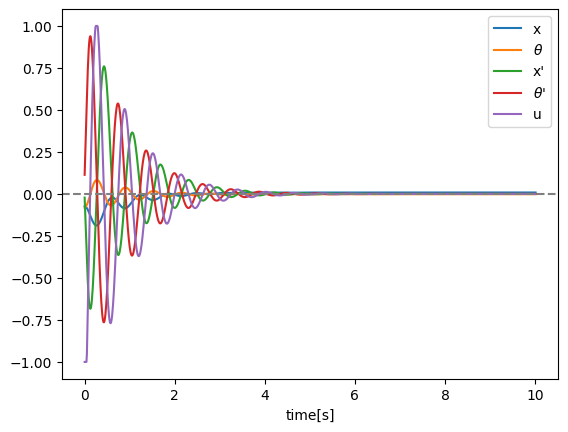

In [ ]:
## Main
# We now change the values for the physical properties. If we do not recompute the
# controller gain, we stil use the old gain.
m = 3 # wrong weight of pole
M = 6 # wrong weight of cart
l = 0.6 # wrong length
g = 24.79 # we are now on jupyter (pun inteded) but we created our system for earth
k = 50
mj_model = get_mj_model(m,M,l,g,k)
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model)
# Simulate model
trajectory, actions = simulate(gain)
print(f"J = {cost(trajectory,actions,Q,R)}")

### Tasks
1. Try around with different values for the physical properties. How much error can our controller support?
2. Recompute the control gain with the new values. Are there values where the pole can't be stabilized? Why?